# Mean wind stress fields in Beaufort

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38197")
client

<Client: 'tcp://127.0.0.1:38197' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open EXFtaux zarr store - Wind stress in the model +x direction
EXFtaux_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFtaux_AVG_DAILY.ZARR/', s3_options)

# open EXFtauy zarr store - Wind stress in the model +y direction
EXFtauy_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFtauy_AVG_DAILY.ZARR/', s3_options)

In [8]:
# Select beaufort sea region
taux_beaufort = EXFtaux_da.EXFtaux.rename({'i_g':'i'}).isel(i=slice(450,750),j=slice(110,390))
tauy_beaufort = EXFtauy_da.EXFtauy.rename({'j_g':'j'}).isel(i=slice(450,750),j=slice(110,390))

### Rotate the dataset so Alaska is on the bottom

In [9]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 3D xarray.DataArray (time, i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('time', 'i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('time', 'i', 'j').
    """
    rotated = np.rot90(da,3,axes=[1,2])
    
    out = xr.DataArray(
        data=rotated,
        dims=('time','i','j'),
        coords={
            'time': da['time'],
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [10]:
# Rotate the fields so that alaska is on the bottom
taux_beaufort_rot = rotate_dataarray_90ccw(taux_beaufort)
tauy_beaufort_rot = rotate_dataarray_90ccw(tauy_beaufort)

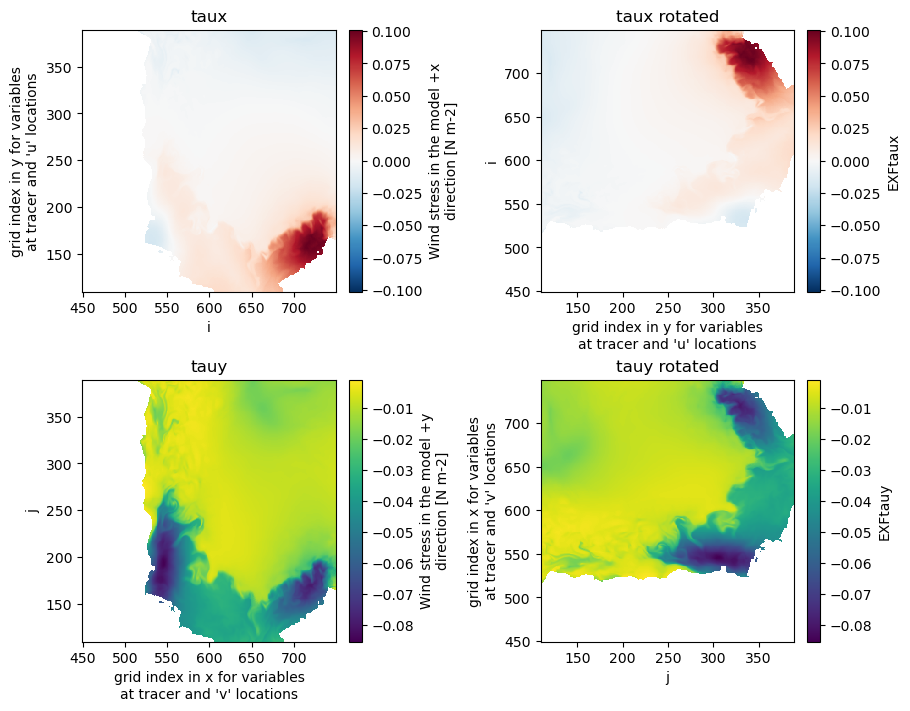

In [11]:
# Double check rotation
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,7],layout='constrained')
taux_beaufort.isel(time=200).plot(ax=ax1);
taux_beaufort_rot.isel(time=200).plot(ax=ax2);
tauy_beaufort.isel(time=200).plot(ax=ax3);
tauy_beaufort_rot.isel(time=200).plot(ax=ax4);
ax1.set_title("taux")
ax2.set_title("taux rotated")
ax3.set_title("tauy")
ax4.set_title("tauy rotated");

In [12]:
# Group by month and compute climatological monthly means
taux_monthly_mean = taux_beaufort_rot.groupby('time.month').mean('time')
tauy_monthly_mean = tauy_beaufort_rot.groupby('time.month').mean('time')

In [13]:
# Need to multiply j by -1 because we are rotating and the vector sign will change
# Also, with the rotation, the i's (x) become j's (y) and the j's (y) become i's (x)
tauy_monthly_mean_rot = taux_monthly_mean
taux_monthly_mean_rot = tauy_monthly_mean*-1

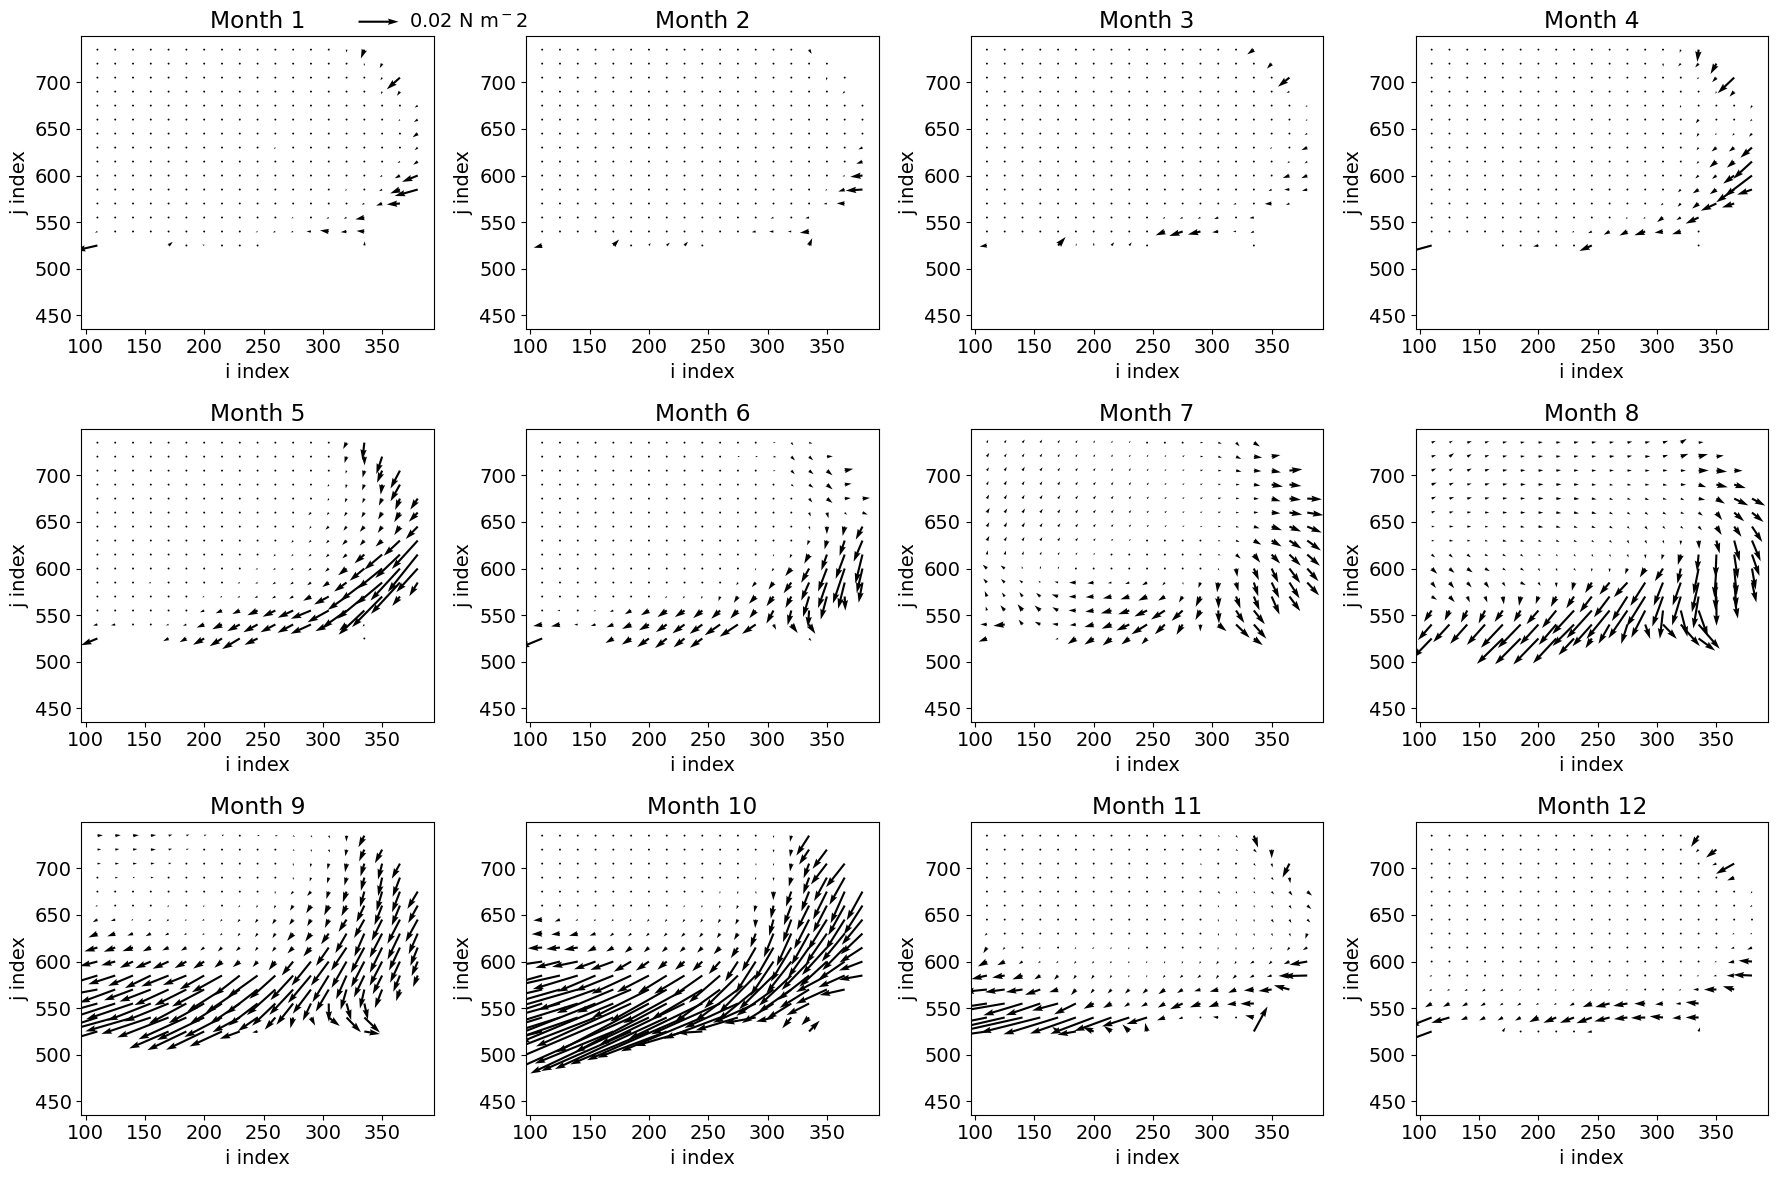

In [92]:
# Subsampling to reduce clutter in quiver plot
step = 15
ii = taux_monthly_mean_rot['i'][::step]
jj = taux_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    taux_sel = taux_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    tauy_sel = tauy_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(taux_sel.values**2 + tauy_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 0.05

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    taux_sel = taux_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    tauy_sel = tauy_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  taux_sel.values, tauy_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 0.02, '0.02 N m${^-2}$',
                     labelpos='E', coordinates='axes')

plt.tight_layout()
plt.show()

In [88]:
# Group by month and compute climatological monthly means
taux_monthly_mean = taux_beaufort.groupby('time.month').mean('time')
tauy_monthly_mean = tauy_beaufort.groupby('time.month').mean('time')

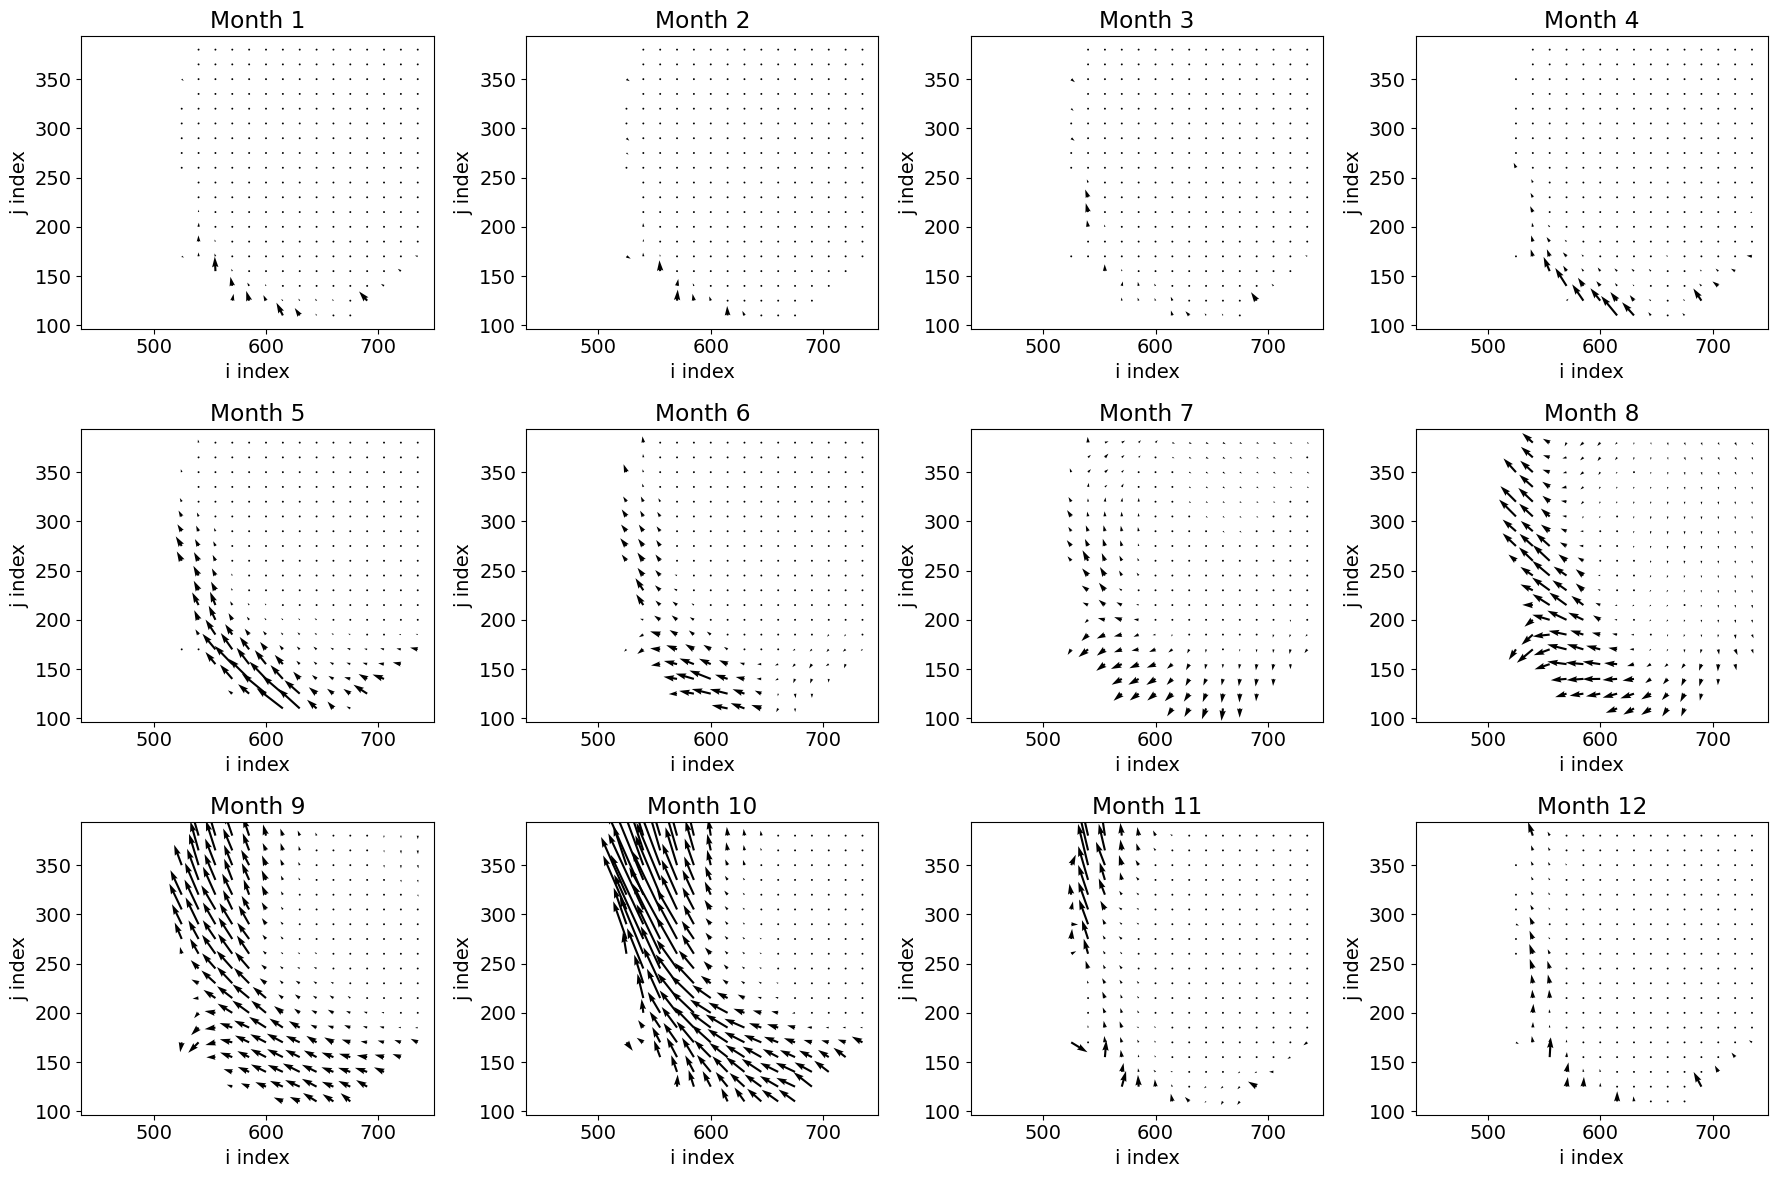

In [93]:
# Subsampling to reduce clutter in quiver plot
step = 15
ii = taux_monthly_mean['i'][::step]
jj = taux_monthly_mean['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(18, 12))
axs = axs.ravel()

# Define a consistent quiver scale
scale = 0.08

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    taux_sel = taux_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    tauy_sel = tauy_monthly_mean.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    i_grid, j_grid = np.meshgrid(ii, jj)
    
    # Use .values to extract data for quiver
    ax.quiver(i_grid, j_grid, taux_sel.values, tauy_sel.values, scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

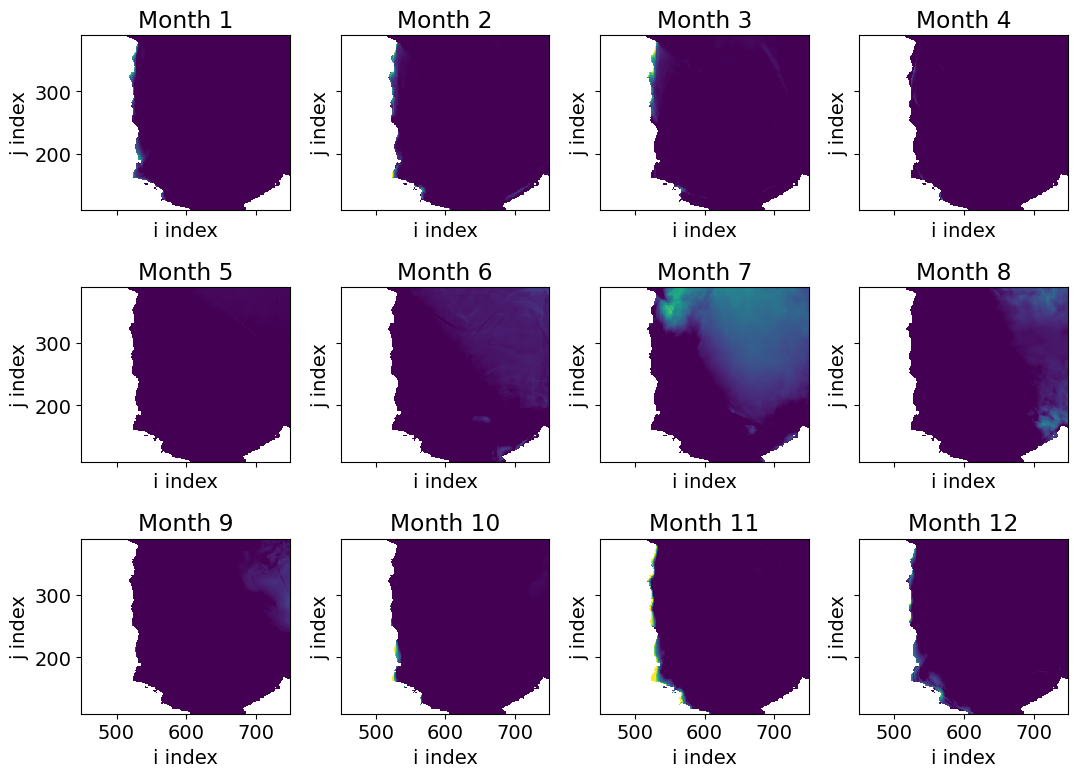

In [103]:
# Just plot each x,y quantity
fig, axs = plt.subplots(3, 4, figsize=(11, 8), sharex=True, sharey=True)
axs = axs.ravel()

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    taux_sel = taux_monthly_mean.isel(month=i)
    # tauy_sel = tauy_monthly_mean.isel(month=i)
    
    # Use .values to extract data for quiver
    taux_sel.plot(ax=ax,vmin=0,vmax=0.005,add_colorbar=False)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

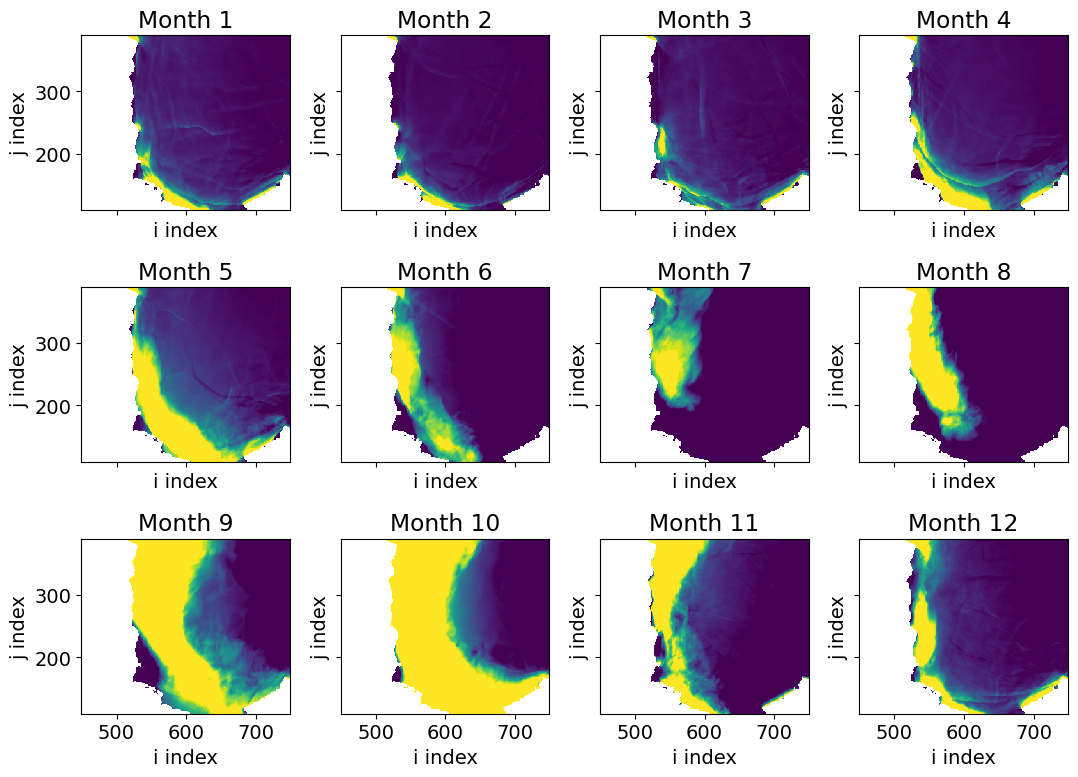

In [110]:
# Just plot each x,y quantity
fig, axs = plt.subplots(3, 4, figsize=(11, 8), sharex=True, sharey=True)
axs = axs.ravel()

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    tauy_sel = tauy_monthly_mean.isel(month=i)
    
    # Use .values to extract data for quiver
    tauy_sel.plot(ax=ax,vmin=0,vmax=0.005,add_colorbar=False)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

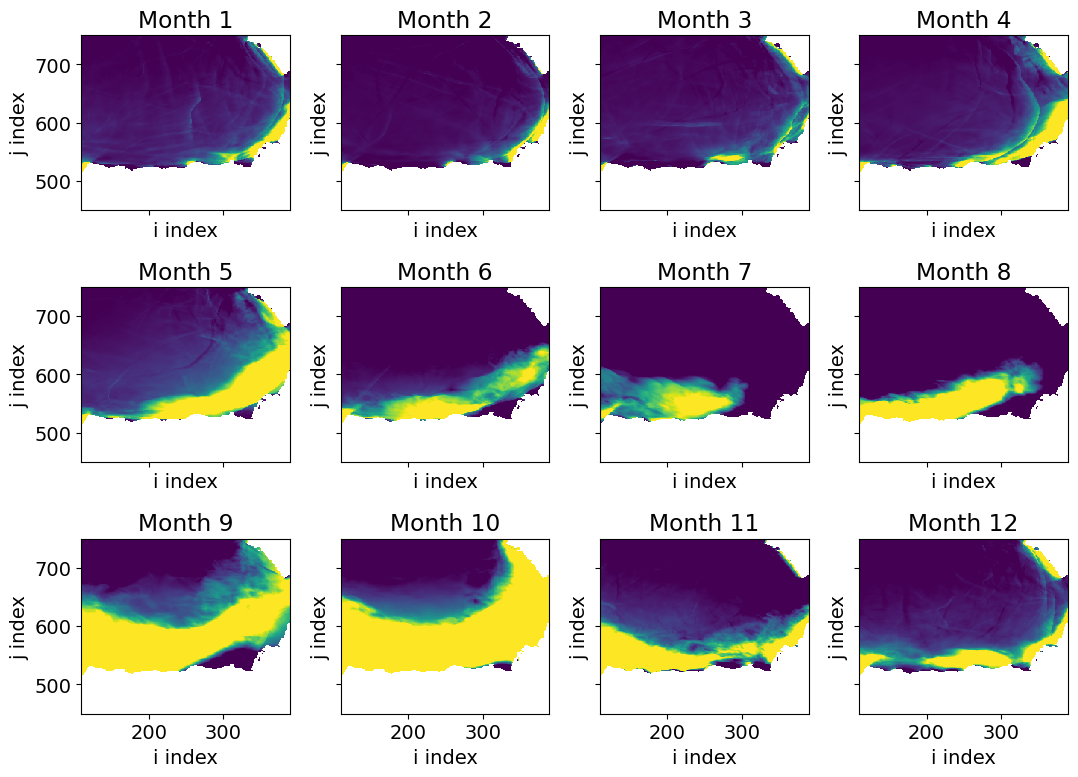

In [113]:
# Just plot each x,y quantity
fig, axs = plt.subplots(3, 4, figsize=(11, 8), sharex=True, sharey=True)
axs = axs.ravel()

for i in range(12):
    ax = axs[i]
    
    # Select the month (months indexed 0 to 11)
    tauy_sel = (taux_monthly_mean_rot*-1).isel(month=i)
    
    # Use .values to extract data for quiver
    tauy_sel.plot(ax=ax,vmin=0,vmax=0.005,add_colorbar=False)
    
    ax.set_title(f"Month {i+1}")
    ax.set_xlabel("i index")
    ax.set_ylabel("j index")

plt.tight_layout()
plt.show()

### Plot every month with SSS below and a contour for SI=15%

In [150]:
# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

In [151]:
# pull out SSS and SIC for beaufort region
sss_beaufort = salt_da.isel(k=0,i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))
sic_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390)).sel(time=slice('2014','2020'))

In [152]:
# Rotate the fields so that alaska is on the bottom
sss_beaufort_rot = rotate_dataarray_90ccw(sss_beaufort)
sic_beaufort_rot = rotate_dataarray_90ccw(sic_beaufort)

In [153]:
# Group by month and compute climatological monthly means
sss_monthly_mean_rot = sss_beaufort_rot.groupby('time.month').mean('time')
sic_monthly_mean_rot = sic_beaufort_rot.groupby('time.month').mean('time')

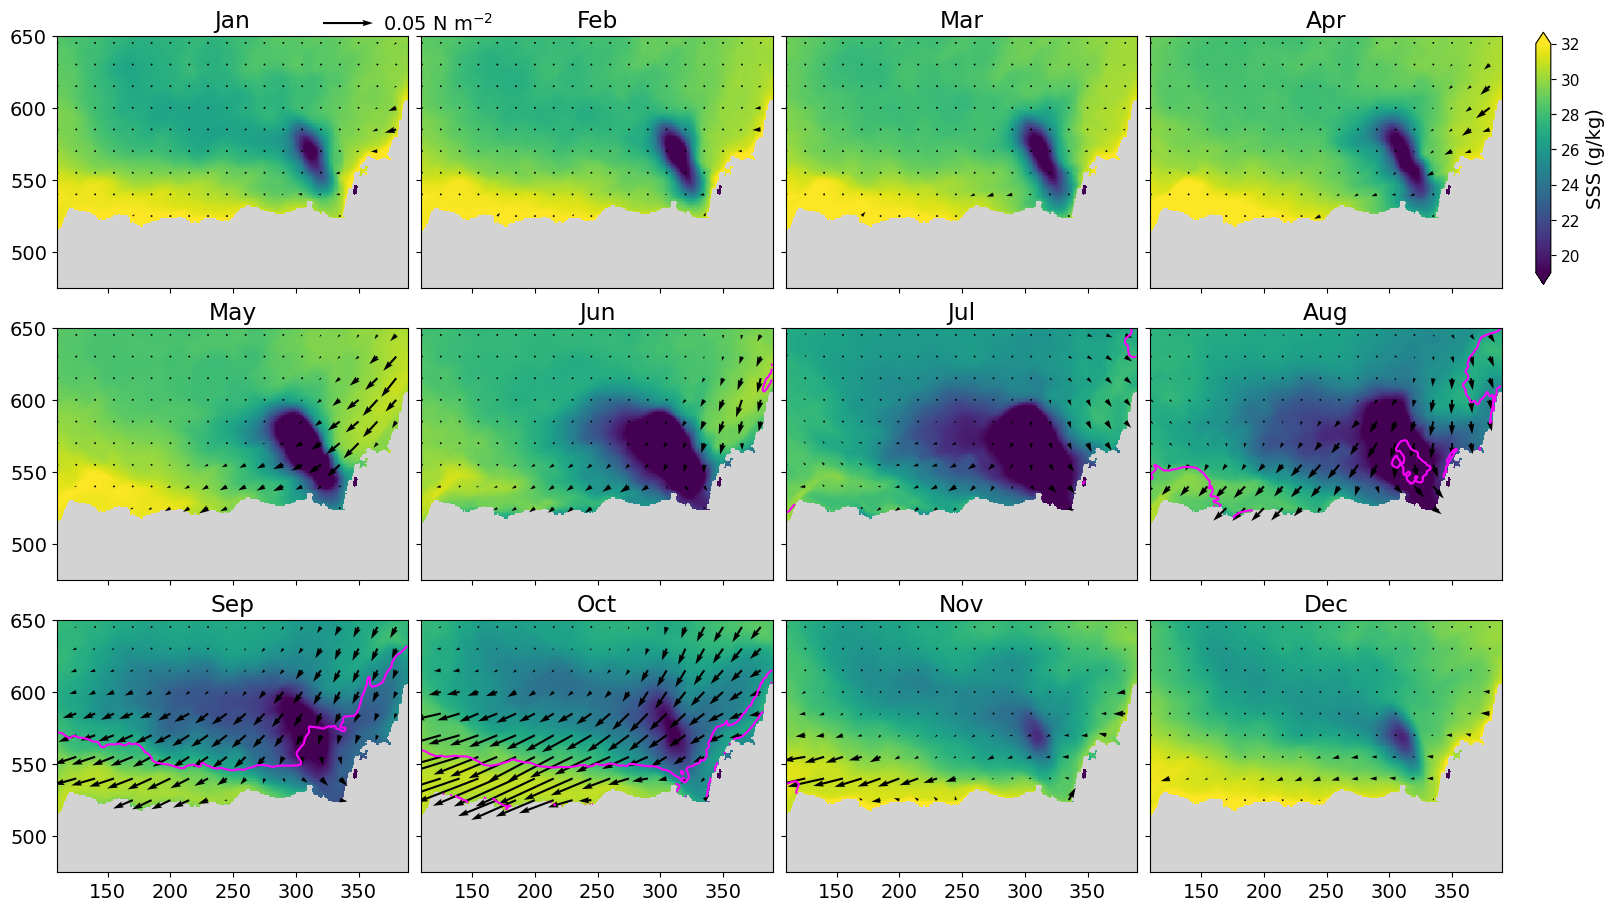

In [174]:
# Subsampling to reduce clutter in quiver plot
plt.rcParams["font.size"] = 14

step = 15
ii = taux_monthly_mean_rot['i'][::step]
jj = taux_monthly_mean_rot['j'][::step]

fig, axs = plt.subplots(3, 4, figsize=(15, 9), sharex=True, sharey=True, layout='constrained')
axs = axs.ravel()

# Compute max vector magnitude across all months for consistent scaling
max_magnitude = 0
for i in range(12):
    taux_sel = taux_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    tauy_sel = tauy_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    mag = np.sqrt(taux_sel.values**2 + tauy_sel.values**2)
    max_magnitude = max(max_magnitude, np.nanmax(mag))

# Define a consistent quiver scale
scale = 0.1

for i in range(12):
    ax = axs[i]

    # Make background gray
    ax.set_facecolor('lightgray')
    
    # Plot SSS for each month
    cbar_plot = sss_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=19,vmax=32,cmap='viridis',add_colorbar=False,extend='both')
    # sic_monthly_mean_rot.isel(month=i).plot(ax=ax,vmin=0,vmax=100,cmap='Blues_r',add_colorbar=False)
    
    # Plot SIC contour at 15% for each month
    sic_monthly_mean_rot.isel(month=i).plot.contour(ax=ax,levels=[15],linewidths=1.5,colors='magenta')
    
    # Select the month (months indexed 0 to 11)
    taux_sel = taux_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    tauy_sel = tauy_monthly_mean_rot.isel(month=i).sel(i=ii, j=jj)
    
    # Meshgrid of i and j for quiver input
    j_grid, i_grid = np.meshgrid(jj, ii)
    
    # Use .values to extract data for quiver
    Q = ax.quiver(j_grid, i_grid,
                  taux_sel.values, tauy_sel.values,
                  scale=scale, angles='uv', scale_units='inches',width=0.006)
    
    # ax.set_title(f"Month {i+1}", fontsize=16)
    ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][i]}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ax.set_ylim(475,650)
    
    # Add a quiver key to one of the plots (say, first subplot)
    if i == 0:
        ax.quiverkey(Q, 0.9, 1.05, 0.05, '0.05 N m$^{-2}$',
                     labelpos='E', coordinates='axes')

# Add a single colorbar for SSS
cbar_ax = fig.add_axes([1.02, 0.69, 0.01, 0.28])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
cbar.set_label("SSS (g/kg)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### Plot each year August-December

In [155]:
def plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,
                    taux_beaufort_rot, tauy_beaufort_rot,
                    year=2014, step=15, scale=0.05):
    """
    Plots August to December monthly means for a specified year (2014–2020)
    from daily data arrays.

    Parameters:
    - sss_beaufort_rot, sic_beaufort_rot, taux_beaufort_rot, tauy_beaufort_rot: xarray DataArrays with 'time', 'i', 'j' dims
    - year: int (2014 to 2020)
    - step: int, subsampling step for quiver arrows
    - scale: float, quiver scale for quiver plot
    """

    plt.rcParams["font.size"] = 14

    # Subsample grid
    ii = taux_beaufort_rot['i'][::step]
    jj = taux_beaufort_rot['j'][::step]

    # Filter data for the selected year
    sss_year = sss_beaufort_rot.sel(time=str(year))
    sic_year = sic_beaufort_rot.sel(time=str(year))
    taux_year = taux_beaufort_rot.sel(time=str(year))
    tauy_year = tauy_beaufort_rot.sel(time=str(year))

    # Compute monthly means
    sss_monthly = sss_year.groupby('time.month').mean('time')
    sic_monthly = sic_year.groupby('time.month').mean('time')
    taux_monthly = taux_year.groupby('time.month').mean('time')
    tauy_monthly = tauy_year.groupby('time.month').mean('time')

    # Set up subplots for August–December (months 8–12)
    fig, axs = plt.subplots(1, 5, figsize=(20, 3.5), sharex=True, sharey=True, layout='constrained')

    # Consistent quiver scale based on max magnitude
    max_magnitude = 0
    for m in range(8, 13):
        taux_sel = taux_monthly.sel(month=m).sel(i=ii, j=jj)
        tauy_sel = tauy_monthly.sel(month=m).sel(i=ii, j=jj)
        mag = np.sqrt(taux_sel**2 + tauy_sel**2)
        max_magnitude = max(max_magnitude, np.nanmax(mag))

    for plot_i, month_i in enumerate(range(8, 13)):
        ax = axs[plot_i]
        ax.set_facecolor('lightgray')

        # Plot SSS
        cbar_plot = sss_monthly.sel(month=month_i).plot(ax=ax, vmin=19, vmax=32, cmap='viridis', add_colorbar=False)

        # Plot SIC 15% contour
        sic_monthly.sel(month=month_i).plot.contour(ax=ax, levels=[15], linewidths=1.5, colors='magenta')

        # Quiver arrows
        taux_sel = taux_monthly.sel(month=month_i).sel(i=ii, j=jj)
        tauy_sel = tauy_monthly.sel(month=month_i).sel(i=ii, j=jj)
        j_grid, i_grid = np.meshgrid(jj, ii)

        Q = ax.quiver(j_grid, i_grid,
                      taux_sel.values, tauy_sel.values,
                      scale=scale, angles='uv', scale_units='inches', width=0.006)

        if plot_i == 0:
            ax.quiverkey(Q, 0.9, 1.05, 0.05, '0.05 N m$^{-2}$',
                         labelpos='E', coordinates='axes')

        ax.set_title(f"{['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][month_i-1]}", fontsize=20)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_ylim(475,650)
        
    fig.text(0.01,1.01,year, fontsize=22)

    # Add a single colorbar for SSS
    cbar_ax = fig.add_axes([1.01, 0.09, 0.01, 0.8])  # left, bottom, width, height
    cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical',extend='both')
    cbar.set_label("SSS (g/kg)")
    cbar.ax.tick_params(labelsize=11)
    
    plt.show()

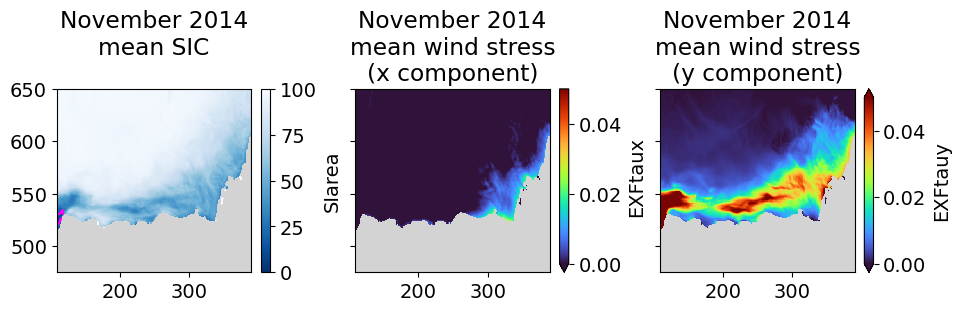

In [156]:
fig, axs = plt.subplots(1, 3, figsize=(9.5, 3), sharex=True, sharey=True, layout='constrained')

sic_beaufort_rot.sel(time='2014-11').mean(dim='time').plot(ax=axs[0],vmin=0,vmax=100,cmap='Blues_r')
sic_beaufort_rot.sel(time='2014-11').mean(dim='time').plot.contour(ax=axs[0],levels=[15],colors='magenta')
tauy_beaufort_rot.sel(time='2014-11').mean(dim='time').plot(ax=axs[2],vmin=0,vmax=0.05,cmap='turbo');
taux_beaufort_rot.sel(time='2014-11').mean(dim='time').plot(ax=axs[1],vmin=0,vmax=0.05,cmap='turbo');

for ax in axs:
    ax.set_facecolor('lightgray')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_ylim(475,650)

axs[0].set_title('November 2014\nmean SIC\n')
axs[1].set_title('November 2014\nmean wind stress\n(x component)');
axs[2].set_title('November 2014\nmean wind stress\n(y component)');

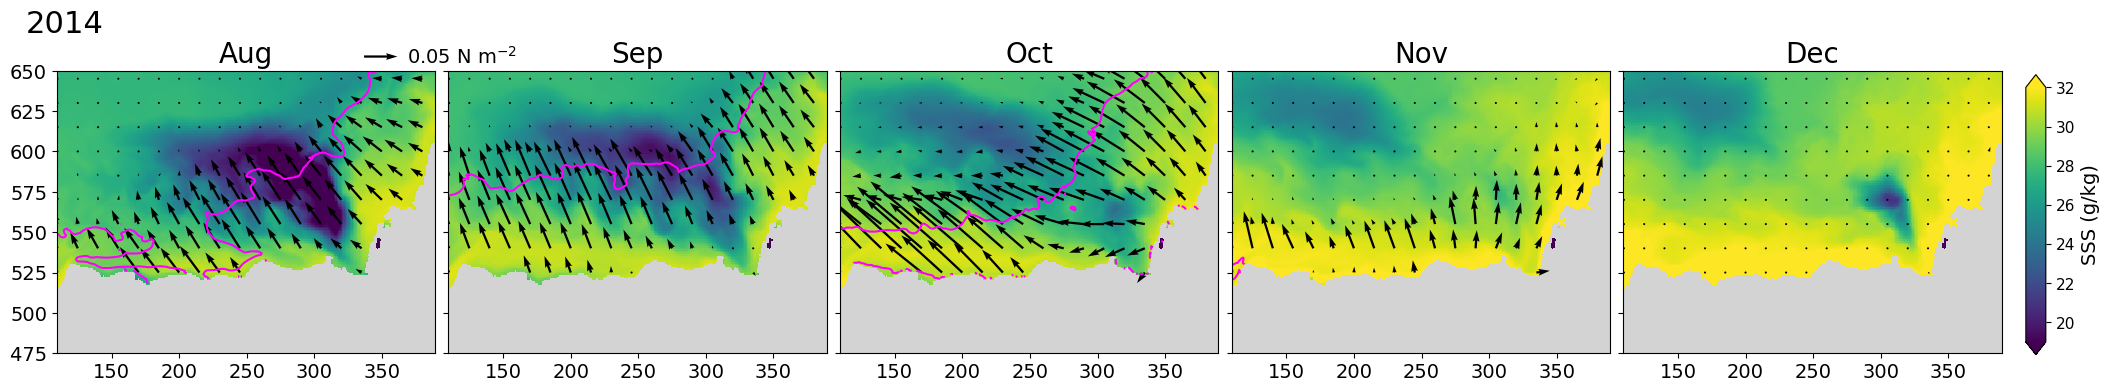

In [166]:
# 2014
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2014,scale=0.15)

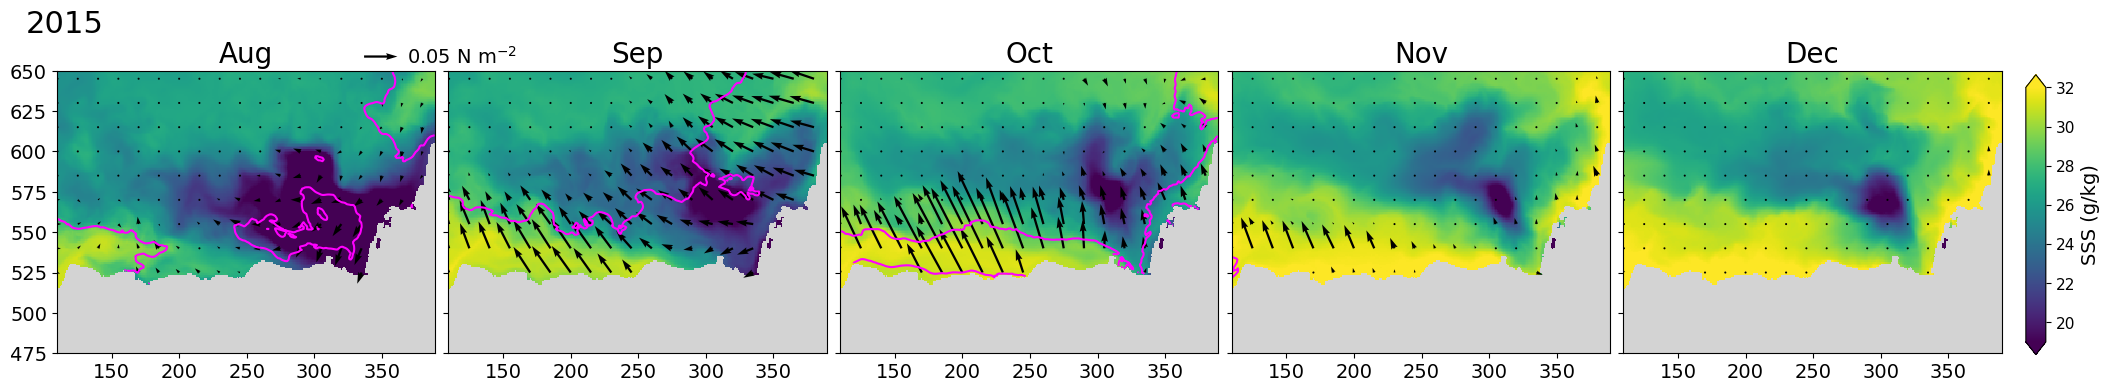

In [167]:
# 2015
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2015,scale=0.15)

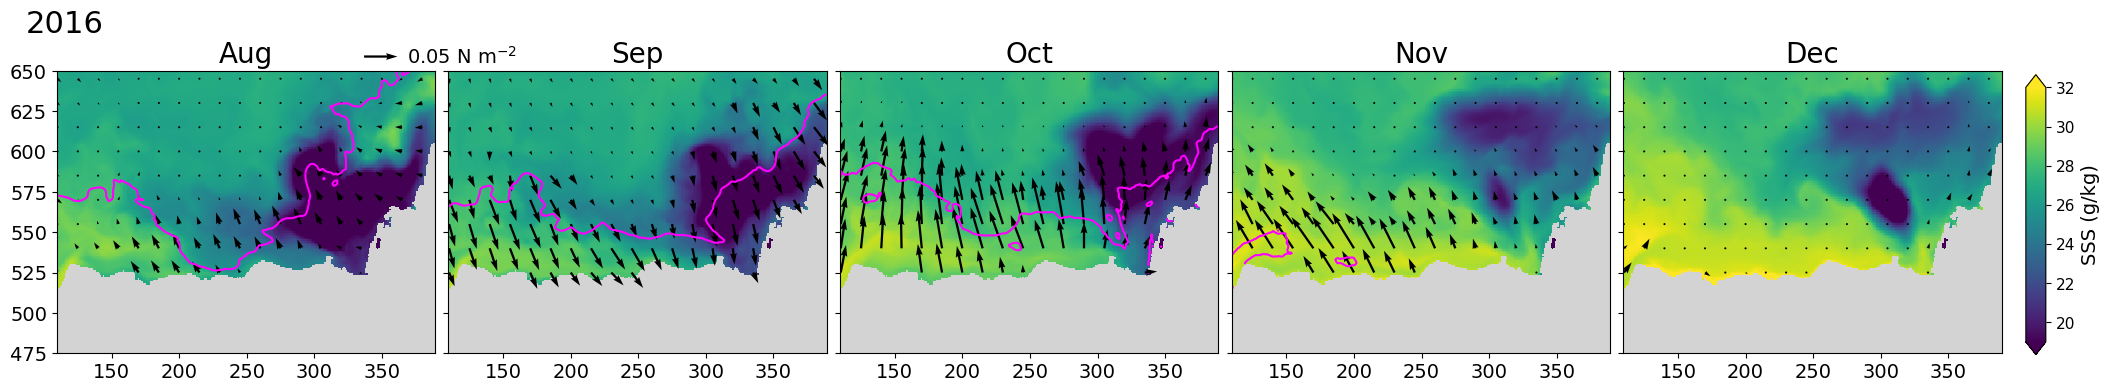

In [168]:
# 2016
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2016,scale=0.15)

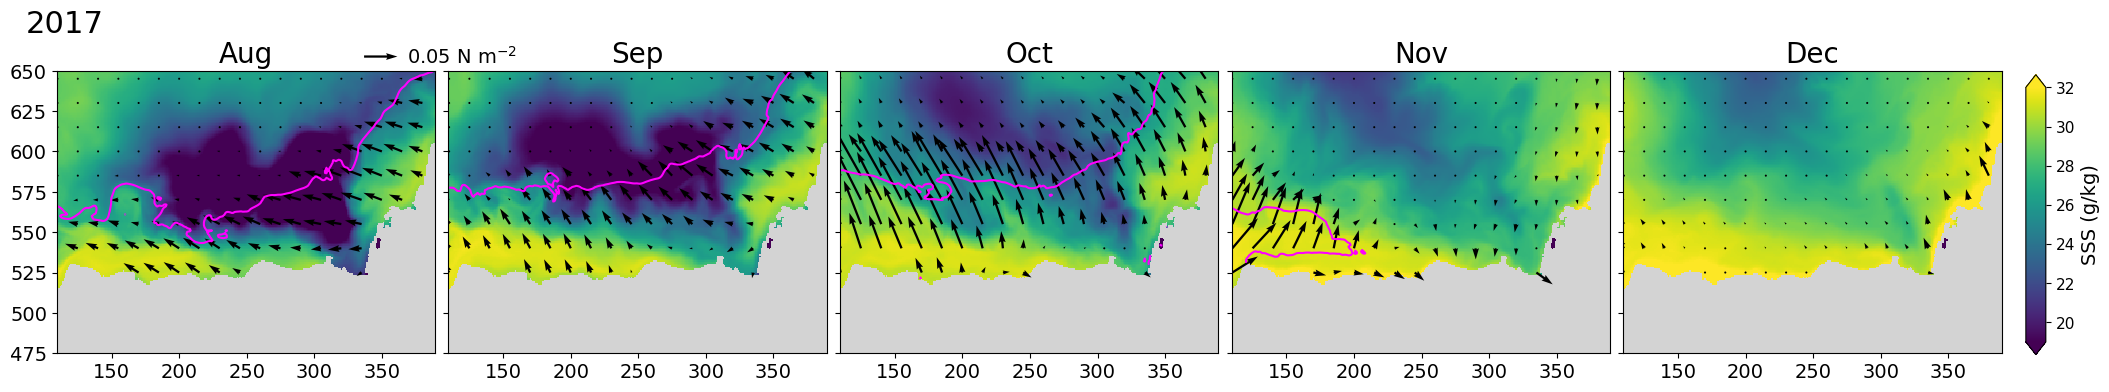

In [169]:
# 2017
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2017,scale=0.15)

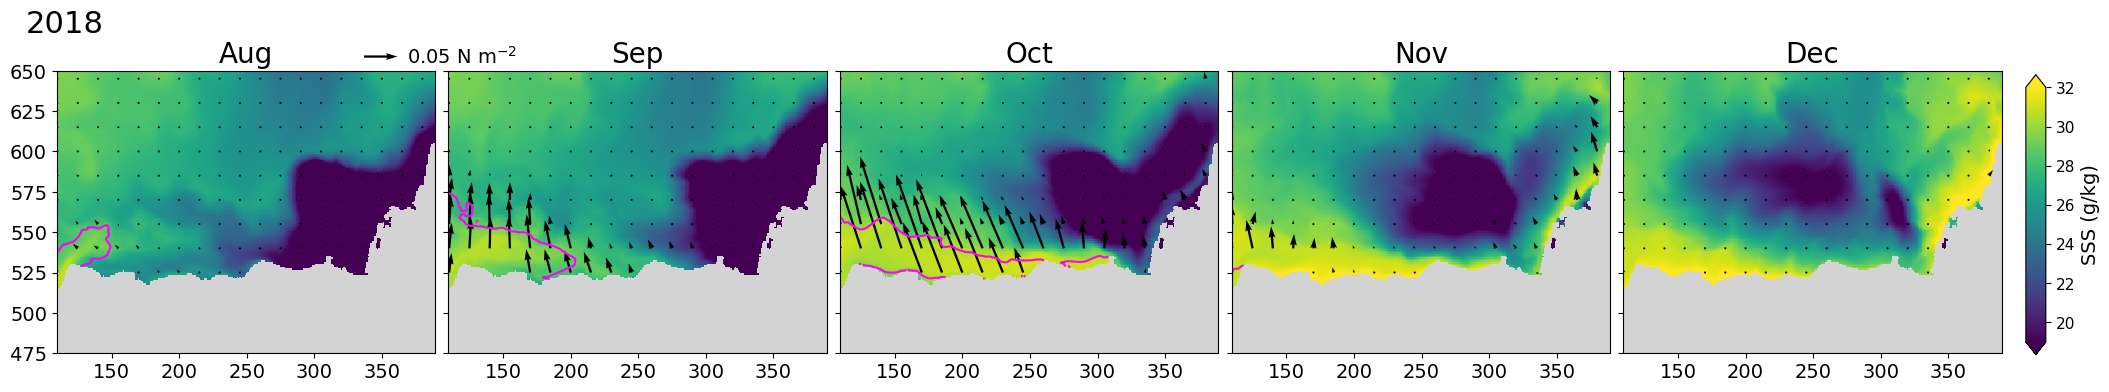

In [170]:
# 2018
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2018,scale=0.15)

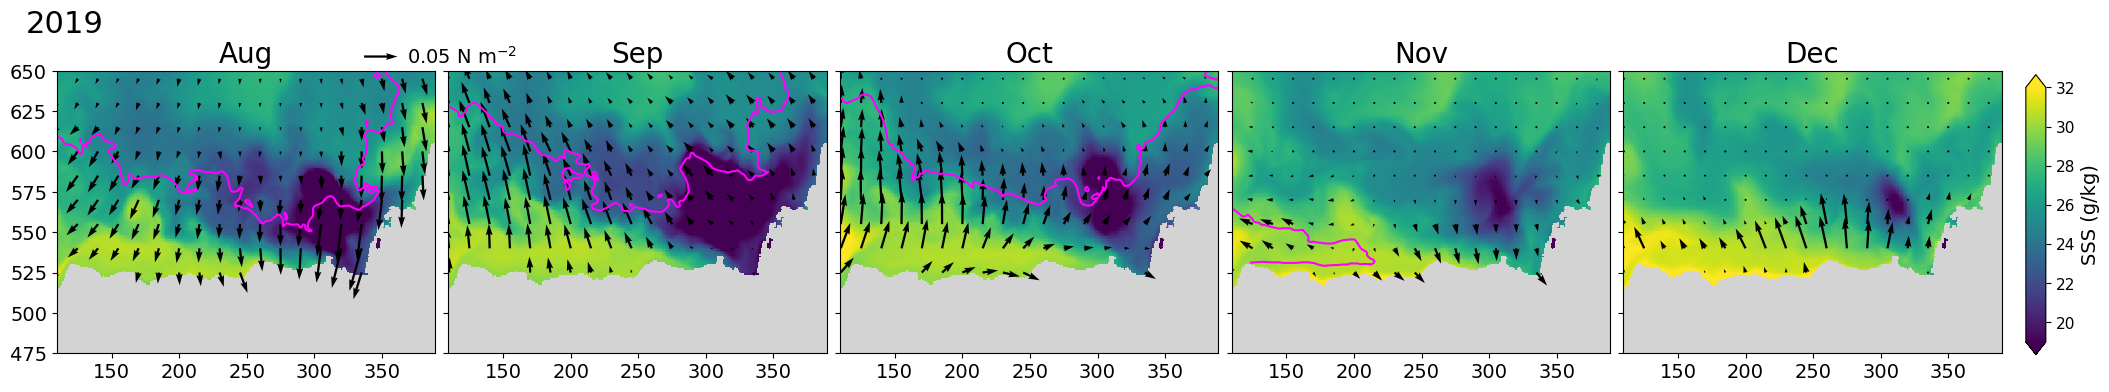

In [171]:
# 2019
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2019,scale=0.15)

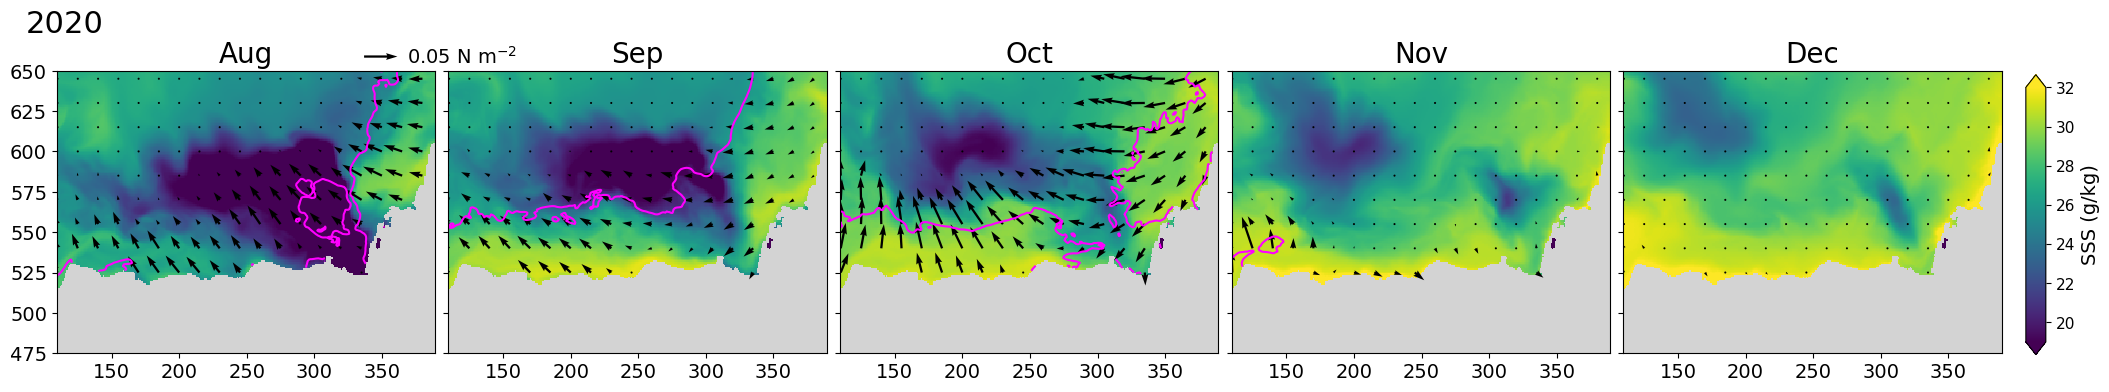

In [172]:
# 2020
plot_aug_to_dec(sss_beaufort_rot, sic_beaufort_rot,taux_beaufort_rot, tauy_beaufort_rot,year=2020,scale=0.15)